In [54]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")   # Phase 3 reads from here

con = duckdb.connect()   # in-memory

# Register every Parquet file as a queryable view so the rest of the
# notebook can just say "FROM application_train" instead of a file path
TABLES = [
    "application_train", "application_test",
    "bureau", "bureau_balance",
    "previous_application", "POS_CASH_balance",
    "installments_payments", "credit_card_balance",
]
for t in TABLES:
    con.execute(f"""
        CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM '{(PROCESSED / f"{t}.parquet").as_posix()}'
    """)

# Data dictionary — your reference for the leakage scan and special codes
col_desc = pd.read_csv(RAW / "HomeCredit_columns_description.csv",
                       encoding="latin-1", index_col=0)

print("Views:", con.execute("SHOW TABLES").df()["name"].tolist())

Views: ['POS_CASH_balance', 'application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'previous_application']


In [55]:
# Shape for train/test
df_train = con.execute("SELECT * FROM application_train").df()
df_test  = con.execute("SELECT * FROM application_test").df()

print(f"Train: {df_train.shape}\n")
print(f"Test: {df_test.shape}")
print(f"Train: {df_train.columns}\n")
print(f"Test: {df_test.columns}")
target_columns = df_train.columns
test_columns = df_test.columns

if "TARGET" in target_columns:
    print("The train df has the Target column")
else:
    print("Train df does not has the Target column")

if "TARGET" not in test_columns:
    print("Test df does not has the Target column")
else:
    print("The test df has the Target column")

if df_train["SK_ID_CURR"].nunique() == len(df_train["SK_ID_CURR"]):
    print("There are no duplications in Train df")
else:
    print("there are duplications in Train df")

if df_test["SK_ID_CURR"].nunique() == len(df_test["SK_ID_CURR"]):
    print("There are no duplications in Test df")
else:
    print("there are duplications in Test df")

train_set_sk = set(df_train["SK_ID_CURR"])
test_set_sk = set(df_test["SK_ID_CURR"])
overlap = train_set_sk & test_set_sk

if overlap == set():
    print("There are no duplication")
else:
    print(f"There are duplication: {overlap}")



Train: (307511, 122)

Test: (48744, 121)
Train: Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

Test: Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 

In [56]:
# splitting to numerical, categorical and binary
def get_column_lists(df):
    binary = [col for col in df.columns if col.startswith("FLAG_")]
    numeric = [col for col in df.select_dtypes(include=["number"]).columns if col not in binary]
    categorical = [col for col in df.select_dtypes(include=['str', 'category']).columns if df[col].nunique() > 2]
    return numeric, categorical, binary

numeric_data, categorical_data, binary_data = get_column_lists(df_train)

print(f"Numeric:     {len(numeric_data)} columns")
print(f"Categorical: {len(categorical_data)} columns")
print(f"Binary FLAG: {len(binary_data)} columns\n")

print(f"Numeric: {numeric_data}\n")
print(f"Categorical: {categorical_data}\n")
print(f"Binary FLAG: {binary_data}")

Numeric:     80 columns
Categorical: 12 columns
Binary FLAG: 28 columns

Numeric: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'C

In [57]:
# STEP 2 Target / bad-rate analysis
df_target = df_train["TARGET"]
print(df_target.describe())
# counting the unique values
print(df_target.value_counts())
print(df_target.value_counts(normalize=True))
total_default = df_target.value_counts()[1]
total_non_default = df_target.value_counts()[0]
print(f"Total number of default is: {total_default}")
print(f"Total number of non default is: {total_non_default}")
default_percent = total_default / len(df_target) * 100
print(f"The % of default is: {default_percent:.3f}")




count   307,511.000
mean          0.081
std           0.272
min           0.000
25%           0.000
50%           0.000
75%           0.000
max           1.000
Name: TARGET, dtype: float64
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0   0.919
1   0.081
Name: proportion, dtype: float64
Total number of default is: 24825
Total number of non default is: 282686
The % of default is: 8.073


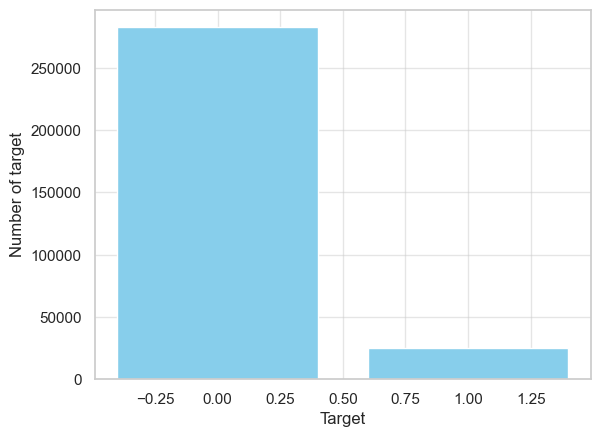

In [58]:
plt.bar(df_target.value_counts().index,df_target.value_counts().values, color="skyblue")
plt.xlabel("Target")
plt.ylabel("Number of target")
plt.show()

In [59]:
# Step 3 — Feature typing, cardinality & special codes
# Cardinality and sentinel for categorical
for i in categorical_data:
    if i in df_train.columns:
        print(f"{i}: {df_train[i].nunique()}")
        print(f"{df_train[i].value_counts()}\n")

CODE_GENDER: 3
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

NAME_TYPE_SUITE: 7
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE: 8
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE: 5
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

NAME_FAMILY_STATUS: 6
NAME_FAMILY_STATUS
Married                 196432
Single

In [60]:
# Step 3 — Feature typing, cardinality & special codes
# Cardinality and sentinel for numerical
for i in numeric_data:
    if i in df_train.columns:
        if -0.5 <= df_train[i].skew() <= 0.5:
            print(f"{i}: 🟢 Skewness is Fairly symmetrical: {df_train[i].skew():.3f} 🟢 \n")
        elif -1 <=df_train[i].skew() <= -0.5:
            print(f"{i}: 🟡 Skewness is Moderately skewed to the LEFT: {df_train[i].skew():.3f} 🟡 \n")
        elif 0.5 <=df_train[i].skew() <= 1:
            print(f"{i}: 🟡 Skewness is Moderately skewed to the RIGHT: {df_train[i].skew():.3f} 🟡 \n")
        elif -1 >= df_train[i].skew():
            print(f"{i}: 🔴 Skewness is Highly skewed to the LEFT: {df_train[i].skew():.3f} 🔴 \n")
        else:
            print(f"{i}: 🔴 Skewness is Highly skewed to the Right: {df_train[i].skew():.3f} 🔴 \n")
        print(f"{i}: {df_train[i].describe().T}\n")
        print(f"{df_train[i].info()}\n")

df_train[df_train["AMT_INCOME_TOTAL"] > 1_000_000]["AMT_INCOME_TOTAL"].value_counts()

value_out = df_train[df_train["AMT_INCOME_TOTAL"] > 1_000_000]["AMT_INCOME_TOTAL"].value_counts()
print(value_out)
df_train["AMT_INCOME_TOTAL"].quantile(0.99)

SK_ID_CURR: 🟢 Skewness is Fairly symmetrical: -0.001 🟢 

SK_ID_CURR: count   307,511.000
mean    278,180.519
std     102,790.175
min     100,002.000
25%     189,145.500
50%     278,202.000
75%     367,142.500
max     456,255.000
Name: SK_ID_CURR, dtype: float64

<class 'pandas.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: SK_ID_CURR
Non-Null Count   Dtype
--------------   -----
307511 non-null  int64
dtypes: int64(1)
memory usage: 2.3 MB
None

TARGET: 🔴 Skewness is Highly skewed to the Right: 3.078 🔴 

TARGET: count   307,511.000
mean          0.081
std           0.272
min           0.000
25%           0.000
50%           0.000
75%           0.000
max           1.000
Name: TARGET, dtype: float64

<class 'pandas.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: TARGET
Non-Null Count   Dtype
--------------   -----
307511 non-null  int64
dtypes: int64(1)
memory usage: 2.3 MB
None

CNT_CHILDREN: 🔴 Skewness is Highly skewed to the Right: 1.975 🔴 

CNT_CHILDREN: c

np.float64(472500.0)

In [61]:
print(df_train["CNT_CHILDREN"].value_counts().sort_index())
print(df_train["CNT_FAM_MEMBERS"].value_counts().sort_index())
inconsistent = df_train[df_train["CNT_CHILDREN"] > df_train["CNT_FAM_MEMBERS"]]
print(f"Inconsistent rows: {len(inconsistent)}")

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64
CNT_FAM_MEMBERS
1.000      67847
2.000     158357
3.000      52601
4.000      24697
5.000       3478
6.000        408
7.000         81
8.000         20
9.000          6
10.000         3
11.000         1
12.000         2
13.000         1
14.000         2
15.000         1
16.000         2
20.000         2
Name: count, dtype: int64
Inconsistent rows: 0


In [62]:
print(df_train["DAYS_EMPLOYED"].describe())
print(f"\nRows with sentinel value (365243): {(df_train['DAYS_EMPLOYED'] == 365243).sum()}")
print(f"% of data: {(df_train['DAYS_EMPLOYED'] == 365243).mean() * 100:.2f}%")

overlap = df_train[
    (df_train["DAYS_EMPLOYED"] == 365243) &
    (df_train["ORGANIZATION_TYPE"] == "XNA")
]["SK_ID_CURR"].nunique()

print(f"Overlap between DAYS_EMPLOYED sentinel and ORGANIZATION_TYPE XNA: {overlap}")
# check if this population has a different bad rate than the rest
sentinel_bad_rate = df_train[df_train["DAYS_EMPLOYED"] == 365243]["TARGET"].mean() * 100
non_sentinel_bad_rate = df_train[df_train["DAYS_EMPLOYED"] != 365243]["TARGET"].mean() * 100

print(f"Bad rate - sentinel population:     {sentinel_bad_rate:.2f}%")
print(f"Bad rate - non-sentinel population: {non_sentinel_bad_rate:.2f}%")
print(f"Population bad rate:                8.07%")

count   307,511.000
mean     63,815.046
std     141,275.767
min     -17,912.000
25%      -2,760.000
50%      -1,213.000
75%        -289.000
max     365,243.000
Name: DAYS_EMPLOYED, dtype: float64

Rows with sentinel value (365243): 55374
% of data: 18.01%
Overlap between DAYS_EMPLOYED sentinel and ORGANIZATION_TYPE XNA: 55374
Bad rate - sentinel population:     5.40%
Bad rate - non-sentinel population: 8.66%
Population bad rate:                8.07%


In [63]:
print("AMT_CREDIT 99%:", df_train["AMT_CREDIT"].quantile(0.99))
print("AMT_GOODS_PRICE 99%:", df_train["AMT_GOODS_PRICE"].quantile(0.99))
print("AMT_ANNUITY 99%:", df_train["AMT_ANNUITY"].quantile(0.99))
print((df_train["AMT_ANNUITY"] > 70006.5).sum())
df_train[df_train["OWN_CAR_AGE"] > 60]["OWN_CAR_AGE"].value_counts().sort_index()

AMT_CREDIT 99%: 1854000.0
AMT_GOODS_PRICE 99%: 1800000.0
AMT_ANNUITY 99%: 70006.5
3070


OWN_CAR_AGE
63.000       2
64.000    2443
65.000     891
69.000       1
91.000       2
Name: count, dtype: int64

In [64]:
print(df_train[df_train["OWN_CAR_AGE"] >= 60]["OWN_CAR_AGE"].value_counts().sort_index())
print(f"\n99th percentile: {df_train['OWN_CAR_AGE'].quantile(0.99)}")
print(f"Total rows with OWN_CAR_AGE = 64: {(df_train['OWN_CAR_AGE'] == 64).sum()}")
print(f"% of cars with age recorded: {df_train['OWN_CAR_AGE'].notna().mean() * 100:.2f}%")
sentinel_bad_rate = df_train[df_train["OWN_CAR_AGE"] == 64]["TARGET"].mean() * 100
non_sentinel_bad_rate = df_train[(df_train["OWN_CAR_AGE"] != 64) & (df_train["OWN_CAR_AGE"].notna())]["TARGET"].mean() * 100

print(f"Bad rate - sentinel (age=64):     {sentinel_bad_rate:.2f}%")
print(f"Bad rate - known car age:         {non_sentinel_bad_rate:.2f}%")

OWN_CAR_AGE
63.000       2
64.000    2443
65.000     891
69.000       1
91.000       2
Name: count, dtype: int64

99th percentile: 64.0
Total rows with OWN_CAR_AGE = 64: 2443
% of cars with age recorded: 34.01%
Bad rate - sentinel (age=64):     8.60%
Bad rate - known car age:         7.21%


In [65]:
other_bad_rate = df_train[df_train["NAME_TYPE_SUITE"].isin(["Other_A", "Other_B"])]["TARGET"].mean() * 100
non_other_bad_rate = df_train[~df_train["NAME_TYPE_SUITE"].isin(["Other_A", "Other_B"]) & df_train["NAME_TYPE_SUITE"].notna()]["TARGET"].mean() * 100

print(f"Bad rate - Other_A and Other_B: {other_bad_rate:.2f}%")
print(f"Bad rate - all other categories: {non_other_bad_rate:.2f}%")

for category in ["Other_A", "Other_B"]:
    bad_rate = df_train[df_train["NAME_TYPE_SUITE"] == category]["TARGET"].mean() * 100
    count = (df_train["NAME_TYPE_SUITE"] == category).sum()
    print(f"{category}: bad rate = {bad_rate:.2f}%, count = {count:,}")

total = len(df_train)
print(f"Other_A: {866/total*100:.2f}% of population")
print(f"Other_B: {1770/total*100:.2f}% of population")

Bad rate - Other_A and Other_B: 9.48%
Bad rate - all other categories: 8.07%
Other_A: bad rate = 8.78%, count = 866
Other_B: bad rate = 9.83%, count = 1,770
Other_A: 0.28% of population
Other_B: 0.58% of population


In [109]:
# Step 4 — Missing value rate
# Train df
df_EXT_SOURCE_123 = df_train[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
def missing_values(x):
    total_missing = x.isna().sum().sort_values(ascending=False)
    missing_rate = (total_missing / len(x) * 100).round(2).sort_values(ascending=False)
    print(f"🟢Percent missing:🟢\n{missing_rate[missing_rate > 0]}\n")
    print(f"🟢Number missing:🟢\n{total_missing[total_missing > 0]}\n")

missing_values(df_train)

🟢Percent missing:🟢
COMMONAREA_AVG             69.870
COMMONAREA_MODE            69.870
COMMONAREA_MEDI            69.870
NONLIVINGAPARTMENTS_MEDI   69.430
NONLIVINGAPARTMENTS_MODE   69.430
                            ...  
OBS_60_CNT_SOCIAL_CIRCLE    0.330
DEF_30_CNT_SOCIAL_CIRCLE    0.330
OBS_30_CNT_SOCIAL_CIRCLE    0.330
EXT_SOURCE_2                0.210
AMT_GOODS_PRICE             0.090
Length: 64, dtype: float64

🟢Number missing:🟢
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64



In [108]:
missing_values(df_EXT_SOURCE_123)
# EXT_SOURCE_1
ext1_missing_bad_rate = df_train[df_train["EXT_SOURCE_1"].isna()]["TARGET"].mean() * 100
ext1_present_bad_rate = df_train[df_train["EXT_SOURCE_1"].notna()]["TARGET"].mean() * 100
print(f"Bad rate - EXT_SOURCE_1 missing: {ext1_missing_bad_rate:.2f}%")
print(f"Bad rate - EXT_SOURCE_1 present: {ext1_present_bad_rate:.2f}%")
# EXT_SOURCE_2
ext1_missing_bad_rate = df_train[df_train["EXT_SOURCE_2"].isna()]["TARGET"].mean() * 100
ext1_present_bad_rate = df_train[df_train["EXT_SOURCE_2"].notna()]["TARGET"].mean() * 100
print(f"\nBad rate - EXT_SOURCE_2 missing: {ext1_missing_bad_rate:.2f}%")
print(f"Bad rate - EXT_SOURCE_2 present: {ext1_present_bad_rate:.2f}%")
# EXT_SOURCE_3
ext1_missing_bad_rate = df_train[df_train["EXT_SOURCE_3"].isna()]["TARGET"].mean() * 100
ext1_present_bad_rate = df_train[df_train["EXT_SOURCE_3"].notna()]["TARGET"].mean() * 100
print(f"\nBad rate - EXT_SOURCE_3 missing: {ext1_missing_bad_rate:.2f}%")
print(f"Bad rate - EXT_SOURCE_3 present: {ext1_present_bad_rate:.2f}%")

🟢Percent missing:🟢
EXT_SOURCE_1   56.380
EXT_SOURCE_3   19.830
EXT_SOURCE_2    0.210
dtype: float64

🟢Number missing:🟢
EXT_SOURCE_1    173378
EXT_SOURCE_3     60965
EXT_SOURCE_2       660
dtype: int64

Bad rate - EXT_SOURCE_1 missing: 8.52%
Bad rate - EXT_SOURCE_1 present: 7.50%

Bad rate - EXT_SOURCE_2 missing: 7.88%
Bad rate - EXT_SOURCE_2 present: 8.07%

Bad rate - EXT_SOURCE_3 missing: 9.31%
Bad rate - EXT_SOURCE_3 present: 7.77%
